# NHC Wind Speed Probabilities — GRIB2

Explores the NHC `tpcprblty` GRIB2 wind speed probability files: fetching, extracting gridded probability fields, and reproducing NHC's own vector polygon pipeline.

## Data sources

### Archive (2006-06-15 onwards)
Files are stored on the NHC FTP server, organised by year and month:
```
https://ftp.nhc.ncep.noaa.gov/wsp/YYYY/MM/tpcprblty.YYYYMMDDHH.grib2.gz
```
Updated every 6 hours (00Z, 06Z, 12Z, 18Z). Both `.grib1.gz` and `.grib2.gz` are
available at each timestamp; `.grib2.gz` starts from 2006-06-15 18Z.

### Operational (current cycle)
The latest file is posted to the download directory:
```
https://ftp.nhc.ncep.noaa.gov/wsp/download/
```
Filename pattern: `WSPtpcprblty.YYYYMMDDHH.gXXX.2.gribpreliminary`  
This is the preliminary operational product before it is moved to the archive.

## Grid
- **Resolution**: 0.5° lat/lon (~55 km)
- **Domain**: 1–60°N, 100°E–1°W (Atlantic + Eastern Pacific basins)
- **Dimensions**: 519 × 119 grid points
- **Coverage**: Basin-wide — all active storms combined into a single field

## Contents
1. **Fetch** — download and decompress to a tempfile
2. **Extract** — read 34/50/64 kt, 120-hr cumulative fields into an `xr.Dataset`
3. **Plot (gridded)** — raster plot with NHC colour scale and cartopy boundaries
4. **Vector polygons** — reproduce NHC's bilinear interpolation → bin → vectorise pipeline

## References
- [DeMaria et al. (2009)](https://www.nhc.noaa.gov/pdf/2009waf_wsp.pdf) — foundational technical paper
- [NHC About Wind Speed Probabilities](https://www.nhc.noaa.gov/about/pdf/About_Windspeed_Probabilities.pdf) — operational product description
- [WSP 2.0 development presentation](https://vlab.noaa.gov/documents/17693964/34445760/7A.3_Hogsett-DeMaria-NHC+TSB.pdf)

In [ ]:
import gzip
import os
import tempfile
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cfgrib
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio.features
import rasterio.transform
import requests
import scipy.interpolate
import shapely.geometry
import shapely.ops
import xarray as xr

# scaledValueOfUpperLimit encodes the wind threshold (scale factor 3, value = m/s × 1000)
KT_TO_SVUL = {34: 17491, 50: 25722, 64: 32924}

NHC_BOUNDS = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
NHC_COLORS = [
    "#d0e8f0",  # <5%
    "#008B00",  # 5-10%
    "#00CD00",  # 10-20%
    "#7FFF00",  # 20-30%
    "#FFFF00",  # 30-40%
    "#FFD700",  # 40-50%
    "#CD8500",  # 50-60%
    "#FF7F00",  # 60-70%
    "#CD0000",  # 70-80%
    "#8B0000",  # 80-90%
    "#8B008B",  # >90%
]
NHC_NORM = mcolors.BoundaryNorm(NHC_BOUNDS, len(NHC_COLORS))
NHC_CMAP = mcolors.ListedColormap(NHC_COLORS)

# NHC probability bin edges and labels — matches the official 5km shapefile schema
BIN_EDGES = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101]
BIN_LABELS = [
    "5-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    ">90%",
]

# Target resolution: ~5km in degrees (matches NHC's NDFD interpolation target)
TARGET_DEG = 5 / 111.32  # ≈ 0.04492°

# Empty GeoDataFrame returned when a threshold has no active probability cells
_EMPTY_GDF = gpd.GeoDataFrame(
    columns=["wind_kt", "percentage", "fill", "geometry"],
    geometry="geometry",
    crs="EPSG:4326",
)

## 1. Fetch

In [3]:
def fetch_wsp_grib2(issuance: str) -> str:
    """
    Download and decompress a NHC GRIB2 wind speed probability file.
    Writes to a temporary file and returns the path.
    Caller is responsible for deleting the file when done.

    Parameters
    ----------
    issuance : ISO timestamp ('2023-08-22T00:00:00Z') or YYYYMMDDHH ('2023082200')

    Returns
    -------
    str  path to the decompressed .grib2 tempfile
    """
    if len(issuance) == 10 and issuance.isdigit():
        ts = datetime.strptime(issuance, "%Y%m%d%H")
    else:
        ts = pd.Timestamp(issuance).to_pydatetime()

    url = (
        f"https://ftp.nhc.ncep.noaa.gov/wsp/"
        f"{ts:%Y}/{ts:%m}/tpcprblty.{ts:%Y%m%d%H}.grib2.gz"
    )
    print(f"Fetching: {url}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    tmp = tempfile.NamedTemporaryFile(suffix=".grib2", delete=False)
    tmp.write(gzip.decompress(r.content))
    tmp.close()
    return tmp.name


grib_path = fetch_wsp_grib2("2023090100")
print(f"Saved to: {grib_path}")

Fetching: https://ftp.nhc.ncep.noaa.gov/wsp/2023/09/tpcprblty.2023090100.grib2.gz
Saved to: /var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/tmpg937f0oj.grib2


## 2. Extract

Use `cfgrib` with `filter_by_keys` to select exactly the messages we want.
The three wind thresholds are encoded as `scaledValueOfUpperLimit` in the GRIB2 metadata.

In [ ]:
def extract_wsp(grib_path: str) -> xr.Dataset:
    """
    Extract 120-hour cumulative wind probability for 34, 50, and 64 kt
    from a decompressed NHC GRIB2 file.

    Returns
    -------
    xr.Dataset with a 'wind_kt' dimension and 'probability' variable (%)
    """
    arrays = []
    for kt, svul in KT_TO_SVUL.items():
        ds = cfgrib.open_dataset(
            grib_path,
            filter_by_keys={
                "shortName": "10si",
                "stepRange": "0-120",
                "scaledValueOfUpperLimit": svul,
            },
            indexpath=None,
            decode_timedelta=False,
        )
        da = ds["si10"].assign_coords(wind_kt=kt).expand_dims("wind_kt")
        arrays.append(da)

    da_all = xr.concat(arrays, dim="wind_kt")
    return da_all.rename("probability").to_dataset()


wsp = extract_wsp(grib_path)
wsp

<xarray.Dataset> Size: 746kB
Dimensions:            (latitude: 119, longitude: 519, wind_kt: 3)
Coordinates:
    time               datetime64[ns] 8B 2023-09-01
    step               float64 8B 120.0
    heightAboveGround  float64 8B 10.0
  * latitude           (latitude) float64 952B 1.0 1.5 2.0 ... 59.0 59.5 60.0
  * longitude          (longitude) float64 4kB 100.0 100.5 101.0 ... 358.5 359.0
    valid_time         datetime64[ns] 8B 2023-09-06
  * wind_kt            (wind_kt) int64 24B 34 50 64
Data variables:
    probability        (wind_kt, latitude, longitude) float32 741kB 0.0 ... 0.0

## 3. Plot — gridded raster

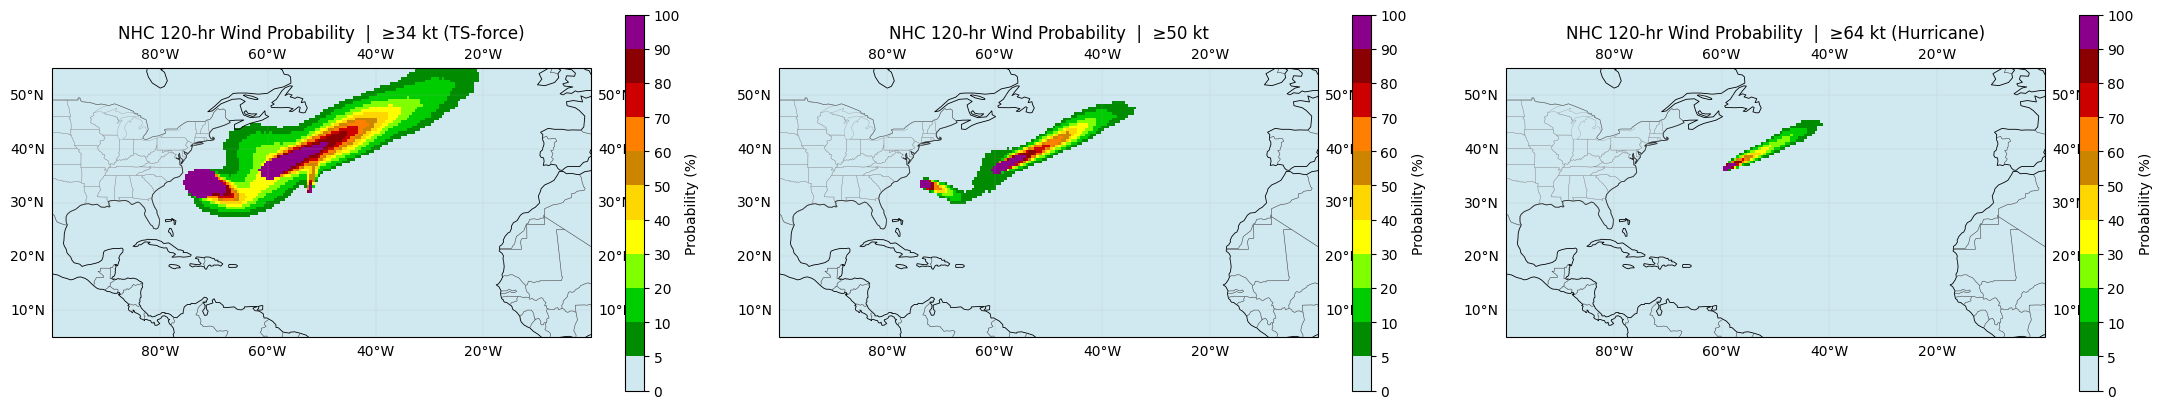

In [ ]:
def plot_wsp(wsp: xr.Dataset, wind_kt: int = 34, ax=None):
    """Plot a single wind threshold from the WSP dataset."""
    da = wsp["probability"].sel(wind_kt=wind_kt)

    # Shift 0–360 → -180–180
    da = da.assign_coords(longitude=(da.longitude % 360) - 360).sortby(
        "longitude"
    )
    da = da.where(da >= 5)  # mask <5% as ocean background

    if ax is None:
        _, ax = plt.subplots(
            figsize=(12, 7), subplot_kw={"projection": ccrs.PlateCarree()}
        )

    ax.set_facecolor("#d0e8f0")
    img = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da.values,
        cmap=NHC_CMAP,
        norm=NHC_NORM,
        shading="nearest",
        transform=ccrs.PlateCarree(),
    )
    plt.colorbar(
        img, ax=ax, label="Probability (%)", ticks=NHC_BOUNDS, shrink=0.8
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#444444")
    ax.add_feature(cfeature.STATES, linewidth=0.2, edgecolor="#888888")

    ax.set_extent([-100, 0, 5, 55], crs=ccrs.PlateCarree())
    ax.gridlines(
        linewidth=0.3,
        alpha=0.4,
        draw_labels=True,
        x_inline=False,
        y_inline=False,
    )

    kt_label = {
        34: "≥34 kt (TS-force)",
        50: "≥50 kt",
        64: "≥64 kt (Hurricane)",
    }
    ax.set_title(f"NHC 120-hr Wind Probability  |  {kt_label[wind_kt]}")
    return ax


fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
for ax, kt in zip(axes, [34, 50, 64]):
    plot_wsp(wsp, wind_kt=kt, ax=ax)
plt.tight_layout()
plt.show()

## 4. Vector polygons — reproducing NHC's method

Following the process described in [DeMaria et al. (2009)](https://www.nhc.noaa.gov/pdf/2009waf_wsp.pdf) and confirmed in the NHC shapefile FGDC metadata:

1. **Bilinear interpolation** from the 0.5° GRIB2 grid to a 5km (~0.045°) grid
2. **Bin** the interpolated float values into the standard NHC probability classes
3. **Vectorise** each bin with `rasterio.features.shapes` (grid-cell union/dissolve)

The output matches the schema of the official NHC 5km GIS shapefiles: one row per probability band, with a `PERCENTAGE` string label and polygon geometry.

In [ ]:
def wsp_to_polygons(wsp: xr.Dataset, wind_kt: int = 34) -> gpd.GeoDataFrame:
    """
    Reproduce NHC's GRIB2 → 5km polygon pipeline for a single wind threshold.

    Steps
    -----
    1. Bilinear interpolation: 0.5° → ~0.045° (5km)
    2. Bin into standard NHC probability classes
    3. Vectorise each bin (rasterio grid-cell dissolve)

    Returns
    -------
    GeoDataFrame with columns: wind_kt, percentage, fill, geometry (EPSG:4326)
    One row per non-empty probability band. Empty GeoDataFrame if no cells exceed 5%.
    """
    da = wsp["probability"].sel(wind_kt=wind_kt)

    # --- Step 1: shift to -180/180 and bilinear-interpolate to 5km grid ---
    da = da.assign_coords(longitude=(da.longitude % 360) - 360).sortby(
        "longitude"
    )

    src_lats = da.latitude.values
    src_lons = da.longitude.values
    dst_lats = np.arange(
        src_lats.min(), src_lats.max() + TARGET_DEG, TARGET_DEG
    )
    dst_lons = np.arange(
        src_lons.min(), src_lons.max() + TARGET_DEG, TARGET_DEG
    )
    dst_lon_grid, dst_lat_grid = np.meshgrid(dst_lons, dst_lats)

    interp = scipy.interpolate.RegularGridInterpolator(
        (src_lats, src_lons),
        da.values.astype(np.float64),
        method="linear",
        bounds_error=False,
        fill_value=0.0,
    )
    grid_5km = interp((dst_lat_grid, dst_lon_grid)).astype(np.float32)

    # --- Steps 2 & 3: bin and vectorise ---
    # rasterio needs a top-left origin affine transform
    transform = rasterio.transform.from_bounds(
        dst_lons.min(),
        dst_lats.min(),
        dst_lons.max(),
        dst_lats.max(),
        grid_5km.shape[1],
        grid_5km.shape[0],
    )
    # rasterio expects row 0 = north, so flip vertically
    grid_flipped = np.flipud(grid_5km)

    rows = []
    for (lo, hi), label in zip(zip(BIN_EDGES[:-1], BIN_EDGES[1:]), BIN_LABELS):
        mask = ((grid_flipped >= lo) & (grid_flipped < hi)).astype(np.uint8)
        if mask.sum() == 0:
            continue
        polys = [
            shapely.geometry.shape(geom)
            for geom, val in rasterio.features.shapes(
                mask, transform=transform
            )
            if val == 1
        ]
        if not polys:
            continue
        rows.append(
            {
                "wind_kt": wind_kt,
                "percentage": label,
                "fill": NHC_COLORS[
                    BIN_LABELS.index(label) + 1
                ],  # +1 skips <5% entry
                "geometry": shapely.ops.unary_union(polys),
            }
        )

    if not rows:
        return _EMPTY_GDF.copy()

    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


# Build polygon GDFs for all three thresholds
polys = {kt: wsp_to_polygons(wsp, wind_kt=kt) for kt in [34, 50, 64]}

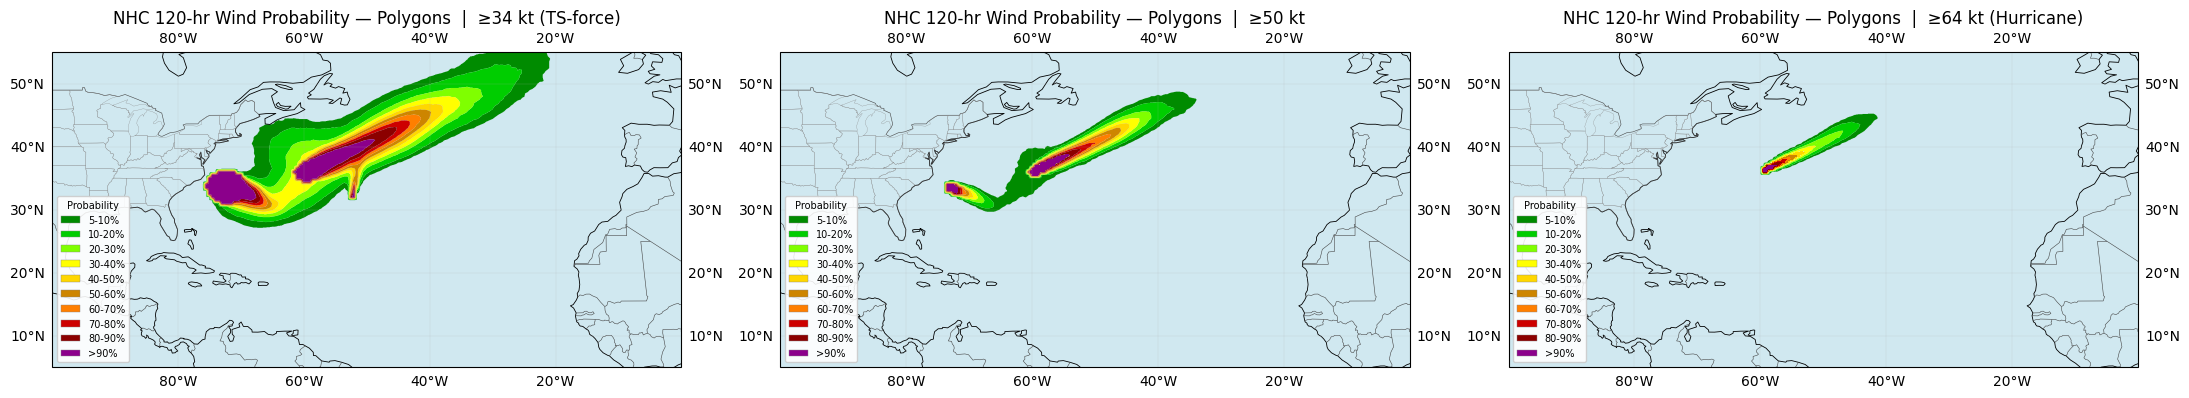

In [7]:
def plot_wsp_polygons(gdf: gpd.GeoDataFrame, wind_kt: int, ax=None):
    """Plot a WSP polygon GeoDataFrame using the NHC colour scheme."""
    if ax is None:
        _, ax = plt.subplots(
            figsize=(12, 7), subplot_kw={"projection": ccrs.PlateCarree()}
        )

    ax.set_facecolor("#d0e8f0")
    ax.set_extent([-100, 0, 5, 55], crs=ccrs.PlateCarree())

    for _, row in gdf.iterrows():
        ax.add_geometries(
            [row.geometry],
            crs=ccrs.PlateCarree(),
            facecolor=row["fill"],
            edgecolor="none",
        )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#444444")
    ax.add_feature(cfeature.STATES, linewidth=0.2, edgecolor="#888888")
    ax.gridlines(
        linewidth=0.3,
        alpha=0.4,
        draw_labels=True,
        x_inline=False,
        y_inline=False,
    )

    handles = [
        mpatches.Patch(
            facecolor=color, edgecolor="#888", linewidth=0.3, label=label
        )
        for label, color in zip(BIN_LABELS, NHC_COLORS[1:])
    ]
    ax.legend(
        handles=handles,
        title="Probability",
        loc="lower left",
        fontsize=7,
        title_fontsize=7,
        framealpha=0.9,
    )

    kt_label = {
        34: "≥34 kt (TS-force)",
        50: "≥50 kt",
        64: "≥64 kt (Hurricane)",
    }
    ax.set_title(
        f"NHC 120-hr Wind Probability — Polygons  |  {kt_label[wind_kt]}"
    )
    return ax


fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
for ax, kt in zip(axes, [34, 50, 64]):
    plot_wsp_polygons(polys[kt], wind_kt=kt, ax=ax)
plt.tight_layout()
plt.show()

In [8]:
os.unlink(grib_path)